# SVD Collaborative Filtering — Personalized Product Recommendations

**Part 2a of the Recommendation System Module**

| Aspect | Detail |
|--------|--------|
| **PRD Requirement** | Suggestion de produits personnalisés (User-Specific Recommendations) |
| **Model** | Truncated SVD (Singular Value Decomposition) |
| **Category** | Matrix Factorization (Collaborative Filtering) |
| **Baseline** | Popularity-Based (Top-N most purchased items for everyone) |
| **Evaluation** | Precision@K, Recall@K, F1@K, NDCG@K |

---

### How SVD Works for Recommendations

SVD decomposes the User × Item interaction matrix into three matrices:

$$A \approx U \cdot \Sigma \cdot V^T$$

- **U** (users × k): Each user represented as a vector in latent space
- **Σ** (k × k): Diagonal matrix of singular values (importance of each factor)
- **Vᵀ** (k × items): Each item represented as a vector in latent space

By keeping only the top-k factors (truncated), we capture the dominant patterns and filter out noise. Reconstructing gives predicted scores for items users haven't tried.

> **Important:** SVD is a **direct decomposition**, not iterative training. There is no loss function, no gradient descent, no epochs. It's a one-shot factorization — and that's perfectly fine for collaborative filtering.

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)  # Reproducibility

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Adjust this path to your dataset location
DATASETS_DIR = os.path.join('..', 'datasets')
SVD_DIR = os.path.join('..', 'SVD')

print('Setup complete.')

Setup complete.


---
## 2. Load Data

In [2]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'enterprise_pos_dataset.csv'), sep='|')
customers_df = pd.read_csv(os.path.join(DATASETS_DIR, 'customers.csv'))

print(f'Transactions:     {len(df):,} rows')
print(f'Unique customers: {df["customer_id"].nunique()}')
print(f'Unique items:     {df["item_name"].nunique()}')
print(f'Columns:          {list(df.columns)}')
df.head()

Transactions:     178,839 rows
Unique customers: 9991
Unique items:     122
Columns:          ['order_details_id', 'order_id', 'order_date', 'order_time', 'item_name', 'category', 'price', 'restaurant_type', 'item_id', 'customer_id', 'cashier_id', 'payment_method', 'table_number', 'is_voided', 'void_reason', 'discount_pct', 'line_total']


,order_details_id,order_id,order_date,order_time,item_name,category,price,restaurant_type,item_id,customer_id,cashier_id,payment_method,table_number,is_voided,void_reason,discount_pct,line_total
0,500000,100000,2023-01-01,07:30 AM,Oatmeal with Berries,Food,5.50,Cafe,80,520,C02,card,12.0,False,NaN,0.0,5.50
1,500001,100000,2023-01-01,07:30 AM,Cold Brew Coffee,Beverage,4.50,Cafe,35,520,C02,card,12.0,False,NaN,0.0,4.50
2,500002,100000,2023-01-01,07:30 AM,Fruit Smoothie,Beverage,6.50,Cafe,50,520,C02,card,12.0,False,NaN,0.0,6.50
3,500003,100001,2023-01-01,08:00 AM,Almond Croissant,Bakery,4.25,Cafe,4,6381,C03,cash,21.0,False,NaN,0.0,4.25
4,500004,100001,2023-01-01,08:00 AM,Everything Bagel with Cream Cheese,Bakery,4.50,Cafe,46,6381,C03,cash,21.0,False,NaN,0.0,4.50


---
## 3. Exploratory Data Analysis

Before building any model, we need to understand the data distribution:
- **Sparsity**: If > 95%, most user-item pairs have no interaction → cold start risk
- **Long tail**: Few items bought by everyone, most items rarely bought
- **User activity**: If typical user buys < 5 unique items, collaborative filtering will struggle

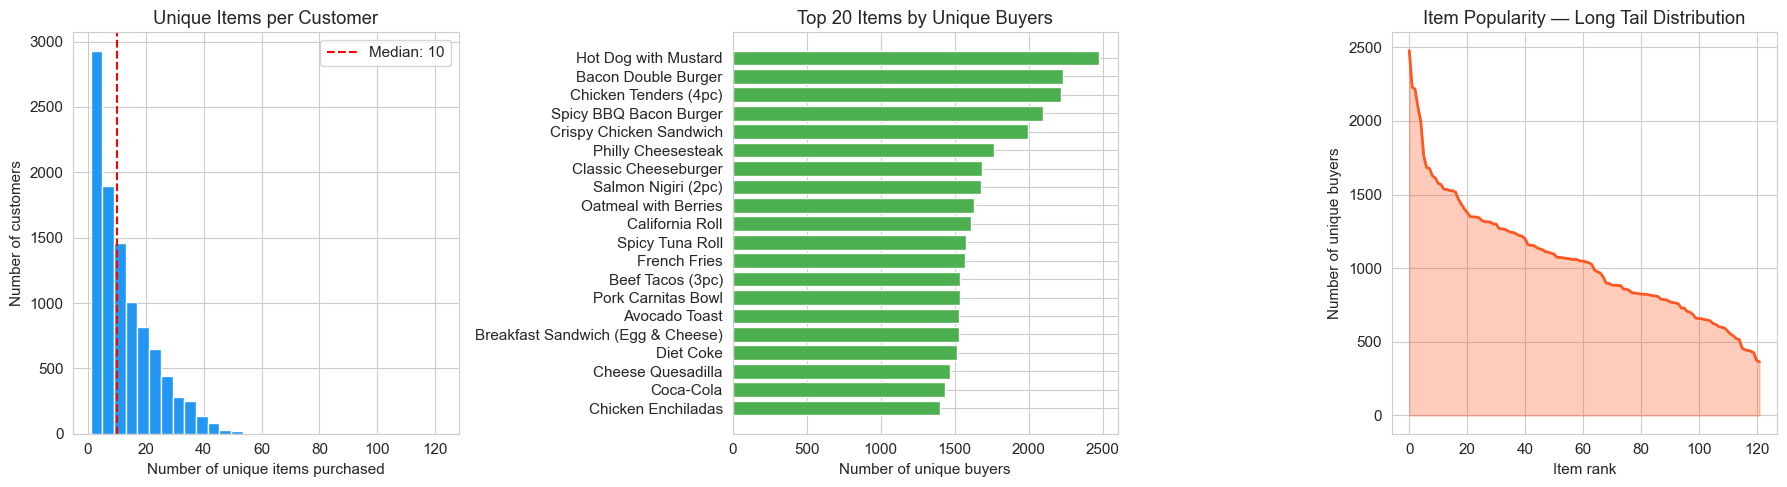


User stats:
  Min unique items per user:    1
  Median unique items per user: 10
  Max unique items per user:    122

Item stats:
  Items bought by only 1 user:  0
  Items bought by 50%+ users:   0


In [3]:
# Purchases per customer
purchases_per_user = df.groupby('customer_id')['item_name'].nunique().reset_index(name='unique_items')

# Purchases per item
purchases_per_item = df.groupby('item_name')['customer_id'].nunique().reset_index(name='unique_buyers')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Unique items per user
axes[0].hist(purchases_per_user['unique_items'], bins=30, color='#2196F3', edgecolor='white')
axes[0].set_title('Unique Items per Customer')
axes[0].set_xlabel('Number of unique items purchased')
axes[0].set_ylabel('Number of customers')
axes[0].axvline(purchases_per_user['unique_items'].median(), color='red', linestyle='--',
                label=f'Median: {purchases_per_user["unique_items"].median():.0f}')
axes[0].legend()

# Plot 2: Top 20 most purchased items
top_items = purchases_per_item.nlargest(20, 'unique_buyers')
axes[1].barh(top_items['item_name'], top_items['unique_buyers'], color='#4CAF50', edgecolor='white')
axes[1].set_title('Top 20 Items by Unique Buyers')
axes[1].set_xlabel('Number of unique buyers')
axes[1].invert_yaxis()

# Plot 3: Long tail distribution
sorted_popularity = purchases_per_item['unique_buyers'].sort_values(ascending=False).values
axes[2].plot(range(len(sorted_popularity)), sorted_popularity, color='#FF5722', linewidth=2)
axes[2].fill_between(range(len(sorted_popularity)), sorted_popularity, alpha=0.3, color='#FF5722')
axes[2].set_title('Item Popularity — Long Tail Distribution')
axes[2].set_xlabel('Item rank')
axes[2].set_ylabel('Number of unique buyers')

plt.tight_layout()
plt.show()

print(f'\nUser stats:')
print(f'  Min unique items per user:    {purchases_per_user["unique_items"].min()}')
print(f'  Median unique items per user: {purchases_per_user["unique_items"].median():.0f}')
print(f'  Max unique items per user:    {purchases_per_user["unique_items"].max()}')
print(f'\nItem stats:')
print(f'  Items bought by only 1 user:  {(purchases_per_item["unique_buyers"] == 1).sum()}')
print(f'  Items bought by 50%+ users:   {(purchases_per_item["unique_buyers"] >= df["customer_id"].nunique() * 0.5).sum()}')

---
## 4. Build User-Item Interaction Matrix

In [4]:
# Count how many times each user purchased each item
user_item = df.groupby(['customer_id', 'item_name']).size().reset_index(name='purchase_count')

# Pivot: users as rows, items as columns
user_item_matrix = user_item.pivot(
    index='customer_id',
    columns='item_name',
    values='purchase_count'
).fillna(0)

# Store indices as lists AND as fast lookup dicts
user_ids = user_item_matrix.index.tolist()
item_names = user_item_matrix.columns.tolist()
user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}  # O(1) lookup instead of O(n)
item_name_to_idx = {name: i for i, name in enumerate(item_names)}

n_users, n_items = user_item_matrix.shape
n_interactions = (user_item_matrix > 0).sum().sum()
sparsity = 1 - (n_interactions / (n_users * n_items))

print(f'Matrix shape:  {n_users} users × {n_items} items')
print(f'Interactions:  {n_interactions:,}')
print(f'Sparsity:      {sparsity:.1%}')
print(f'Max purchases: {user_item_matrix.values.max():.0f} (single user, single item)')

Matrix shape:  9991 users × 122 items
Interactions:  128,063
Sparsity:      89.5%
Max purchases: 38 (single user, single item)


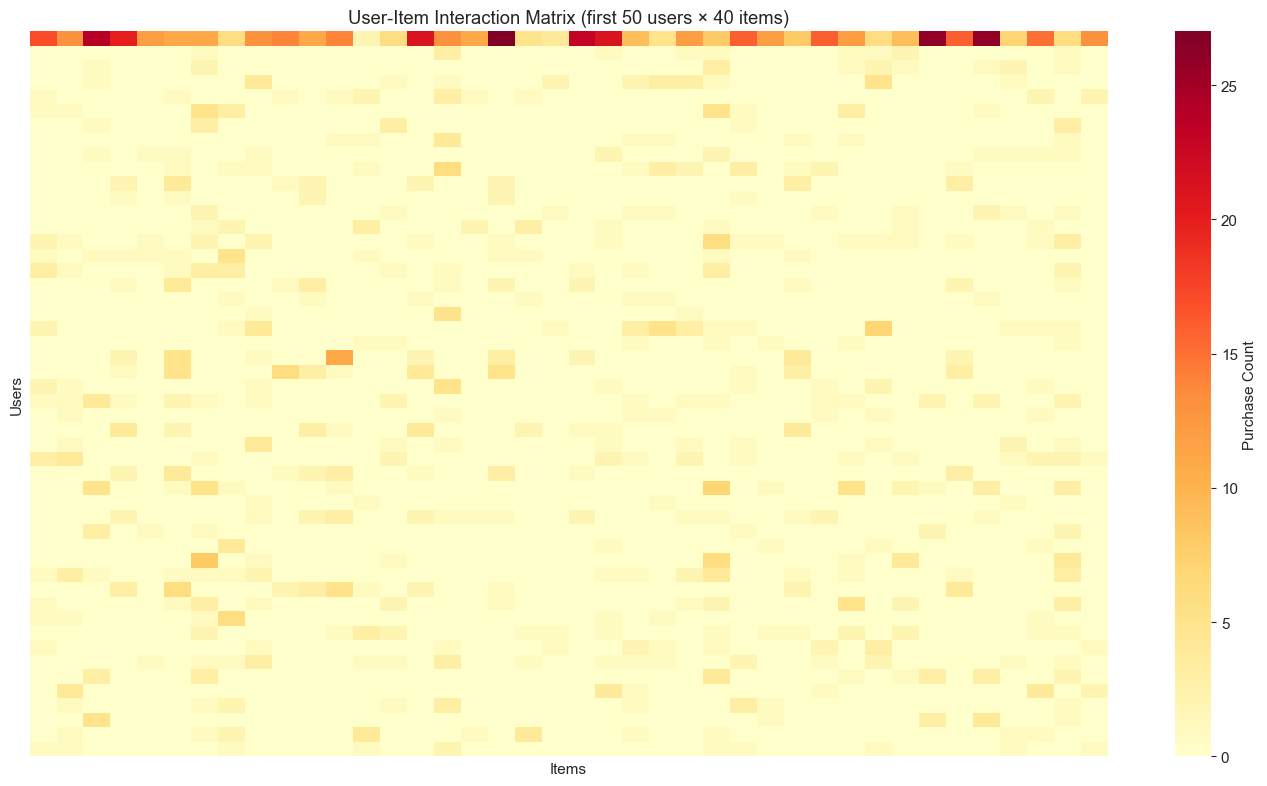

In [5]:
# Visualize the interaction matrix as a heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    user_item_matrix.iloc[:50, :40].values,  # Show a subset for readability
    cmap='YlOrRd',
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Purchase Count'},
    ax=ax
)
ax.set_title('User-Item Interaction Matrix (first 50 users × 40 items)')
ax.set_xlabel('Items')
ax.set_ylabel('Users')
plt.tight_layout()
plt.show()

---
## 5. Train/Test Split

For each user, we hold out 20% of their purchased items for testing. This simulates the real scenario: given what the user already bought, can the model predict what they'll buy next?

**Note:** This is a random split, not temporal. A temporal split (train on past, test on future) would be more realistic for production but requires timestamp granularity we may not have per-item.

In [6]:
train_matrix = user_item_matrix.copy()
test_items = defaultdict(set)  # user_id -> set of held-out items

for uid in user_ids:
    user_purchases = user_item_matrix.loc[uid]
    purchased_items = user_purchases[user_purchases > 0].index.tolist()

    if len(purchased_items) >= 5:  # Only split if user has enough history
        n_test = max(1, int(len(purchased_items) * 0.2))
        held_out = np.random.choice(purchased_items, size=n_test, replace=False)

        for item in held_out:
            test_items[uid].add(item)
            train_matrix.loc[uid, item] = 0  # Zero out in training

n_test_interactions = sum(len(v) for v in test_items.values())
print(f'Train interactions: {(train_matrix > 0).sum().sum():,}')
print(f'Test interactions:  {n_test_interactions:,}')
print(f'Users with test data: {len(test_items)}')
print(f'Avg test items per user: {n_test_interactions / len(test_items):.1f}')

Train interactions: 106,584
Test interactions:  21,479
Users with test data: 7678
Avg test items per user: 2.8


---
## 6. Evaluation Helper Functions

We define reusable evaluation functions so every model (popularity, SVD, and later ALS) is measured identically.

In [7]:
def evaluate_recommendations(predicted_scores, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5):
    """
    Evaluate a recommendation model using Precision@K, Recall@K, F1@K, and NDCG@K.
    
    Parameters:
        predicted_scores: np.array (n_users × n_items) — predicted scores for all user-item pairs
        train_matrix: DataFrame — training interaction matrix (to exclude already-purchased items)
        test_items: dict — {user_id: set of held-out items}
        user_ids: list — ordered user IDs matching matrix rows
        item_names: list — ordered item names matching matrix columns
        user_id_to_idx: dict — fast user_id to row index lookup
        top_k: int — number of recommendations to evaluate
    
    Returns:
        dict with avg precision, recall, f1, ndcg
    """
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    for uid in test_items:
        if uid not in user_id_to_idx:
            continue

        uid_idx = user_id_to_idx[uid]
        user_preds = predicted_scores[uid_idx]

        # Items already purchased in training — exclude from recommendations
        already_purchased = set(train_matrix.columns[train_matrix.loc[uid] > 0])

        # Score only unpurchased items
        candidates = [(i, item, user_preds[i]) for i, item in enumerate(item_names) if item not in already_purchased]
        candidates.sort(key=lambda x: x[2], reverse=True)
        top_n = [item for _, item, _ in candidates[:top_k]]

        # Precision@K and Recall@K
        hits = len(set(top_n) & test_items[uid])
        precision_scores.append(hits / top_k)
        recall_scores.append(hits / len(test_items[uid]))

        # NDCG@K (position-aware: rewards hits at top positions)
        dcg = 0.0
        for rank, item in enumerate(top_n):
            if item in test_items[uid]:
                dcg += 1.0 / np.log2(rank + 2)  # rank+2 because rank is 0-indexed
        # Ideal DCG: all hits at top positions
        ideal_hits = min(len(test_items[uid]), top_k)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)
    avg_f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    avg_ndcg = np.mean(ndcg_scores)

    return {
        'precision@k': avg_precision,
        'recall@k': avg_recall,
        'f1@k': avg_f1,
        'ndcg@k': avg_ndcg
    }


def print_metrics(name, metrics):
    """Pretty print evaluation metrics."""
    print(f'  {name:<25} | Precision@5: {metrics["precision@k"]:.4f} | Recall@5: {metrics["recall@k"]:.4f} | F1@5: {metrics["f1@k"]:.4f} | NDCG@5: {metrics["ndcg@k"]:.4f}')


print('Evaluation functions defined.')

Evaluation functions defined.


---
## 7. Baseline — Popularity Recommender

**This is critical.** Before claiming SVD is useful, we need to prove it beats the dumbest possible approach: *recommend the most popular items to everyone.*

If SVD can't beat this, it's adding complexity for zero value.

In [8]:
# Popularity baseline: score each item by total purchase count across all users in TRAINING data
item_popularity = train_matrix.sum(axis=0).values  # shape: (n_items,)

# Every user gets the same scores (popularity is not personalized)
popularity_scores = np.tile(item_popularity, (n_users, 1))  # shape: (n_users, n_items)

popularity_metrics = evaluate_recommendations(
    popularity_scores, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5
)

print('--- BASELINE: Popularity Recommender ---')
print_metrics('Popularity (Top-5)', popularity_metrics)
print('\nThis is the bar SVD must beat. If it can\'t, SVD is useless for this dataset.')

--- BASELINE: Popularity Recommender ---
  Popularity (Top-5)        | Precision@5: 0.0590 | Recall@5: 0.1018 | F1@5: 0.0747 | NDCG@5: 0.0994

This is the bar SVD must beat. If it can't, SVD is useless for this dataset.


---
## 8. SVD — Hyperparameter Search over k (Latent Factors)

The key hyperparameter for truncated SVD is **k** — the number of latent factors.
- Too small → underfitting, can't capture enough patterns
- Too large → overfitting, captures noise instead of signal

Rule of thumb: start around √min(n_users, n_items)

In [9]:
# Mean-center the matrix (subtract each user's mean — improves SVD significantly)
train_np = train_matrix.values.astype(float)
user_means = np.mean(train_np, axis=1).reshape(-1, 1)
train_centered = train_np - user_means

# Convert to sparse for efficiency
train_sparse = csr_matrix(train_centered)

# Sweep over k values
K_VALUES = [5, 10, 15, 20, 30, 50]
svd_results = {}

print(f'Matrix shape: {train_sparse.shape}')
print(f'Testing k values: {K_VALUES}\n')

for k in K_VALUES:
    # Ensure k < min(matrix dimensions)
    if k >= min(train_sparse.shape) - 1:
        print(f'  k={k} skipped (too large for matrix dimensions)')
        continue

    # SVD decomposition: A ≈ U × Σ × Vᵀ
    U, sigma, Vt = svds(train_sparse, k=k)

    # Reconstruct predicted scores
    sigma_diag = np.diag(sigma)
    predicted = np.dot(np.dot(U, sigma_diag), Vt) + user_means

    # Evaluate
    metrics = evaluate_recommendations(
        predicted, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5
    )
    svd_results[k] = metrics
    print_metrics(f'SVD (k={k})', metrics)

# Find best k
best_k = max(svd_results, key=lambda k: svd_results[k]['f1@k'])
print(f'\n>>> Best k = {best_k} (by F1@5: {svd_results[best_k]["f1@k"]:.4f})')

Matrix shape: (9991, 122)
Testing k values: [5, 10, 15, 20, 30, 50]

  SVD (k=5)                 | Precision@5: 0.1953 | Recall@5: 0.3621 | F1@5: 0.2538 | NDCG@5: 0.3185
  SVD (k=10)                | Precision@5: 0.2040 | Recall@5: 0.3736 | F1@5: 0.2639 | NDCG@5: 0.3285
  SVD (k=15)                | Precision@5: 0.1916 | Recall@5: 0.3532 | F1@5: 0.2484 | NDCG@5: 0.3050
  SVD (k=20)                | Precision@5: 0.1830 | Recall@5: 0.3369 | F1@5: 0.2372 | NDCG@5: 0.2917
  SVD (k=30)                | Precision@5: 0.1639 | Recall@5: 0.3028 | F1@5: 0.2127 | NDCG@5: 0.2618
  SVD (k=50)                | Precision@5: 0.1293 | Recall@5: 0.2435 | F1@5: 0.1689 | NDCG@5: 0.2131

>>> Best k = 10 (by F1@5: 0.2639)


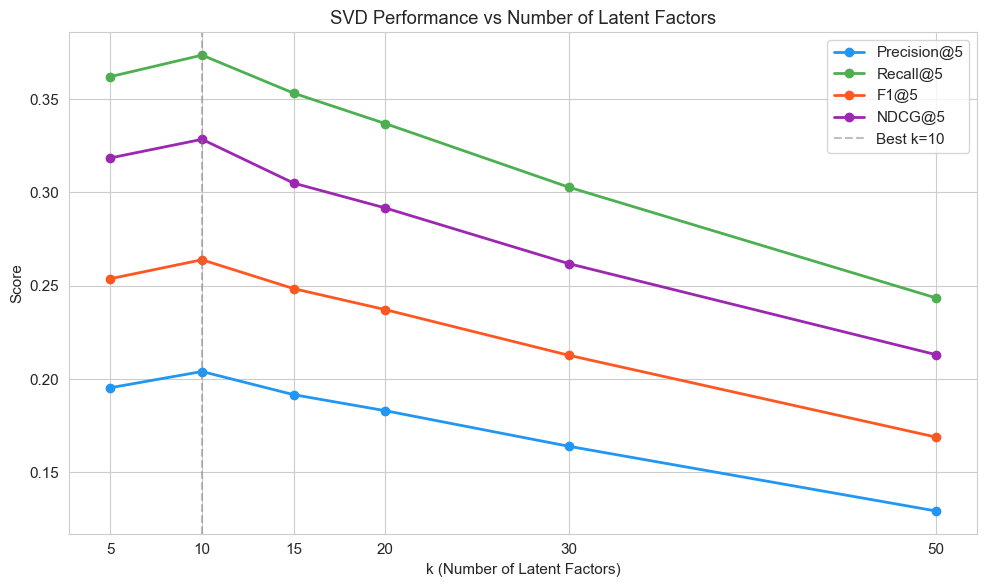

In [12]:
# Visualize k sweep results
ks = sorted(svd_results.keys())
metrics_names = ['precision@k', 'recall@k', 'f1@k', 'ndcg@k']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
labels = ['Precision@5', 'Recall@5', 'F1@5', 'NDCG@5']

fig, ax = plt.subplots(figsize=(10, 6))

for metric, color, label in zip(metrics_names, colors, labels):
    values = [svd_results[k][metric] for k in ks]
    ax.plot(ks, values, marker='o', linewidth=2, color=color, label=label)

ax.axvline(best_k, color='gray', linestyle='--', alpha=0.5, label=f'Best k={best_k}')
ax.set_xlabel('k (Number of Latent Factors)')
ax.set_ylabel('Score')
ax.set_title('SVD Performance vs Number of Latent Factors')
ax.legend()
ax.set_xticks(ks)
plt.tight_layout()
plt.show()

---
## 9. SVD vs Popularity — Direct Comparison

In [13]:
best_svd_metrics = svd_results[best_k]

print('=' * 80)
print('MODEL COMPARISON: SVD vs Popularity Baseline')
print('=' * 80)
print_metrics('Popularity Baseline', popularity_metrics)
print_metrics(f'SVD (k={best_k})', best_svd_metrics)
print('-' * 80)

# Improvement calculation
for metric in ['precision@k', 'recall@k', 'f1@k', 'ndcg@k']:
    baseline_val = popularity_metrics[metric]
    svd_val = best_svd_metrics[metric]
    if baseline_val > 0:
        improvement = (svd_val - baseline_val) / baseline_val * 100
        direction = '↑' if improvement > 0 else '↓'
        print(f'  {metric}: {direction} {abs(improvement):.1f}% vs baseline')
    else:
        print(f'  {metric}: baseline is 0, SVD = {svd_val:.4f}')

MODEL COMPARISON: SVD vs Popularity Baseline
  Popularity Baseline       | Precision@5: 0.0590 | Recall@5: 0.1018 | F1@5: 0.0747 | NDCG@5: 0.0994
  SVD (k=10)                | Precision@5: 0.2040 | Recall@5: 0.3736 | F1@5: 0.2639 | NDCG@5: 0.3285
--------------------------------------------------------------------------------
  precision@k: ↑ 245.7% vs baseline
  recall@k: ↑ 267.1% vs baseline
  f1@k: ↑ 253.2% vs baseline
  ndcg@k: ↑ 230.4% vs baseline


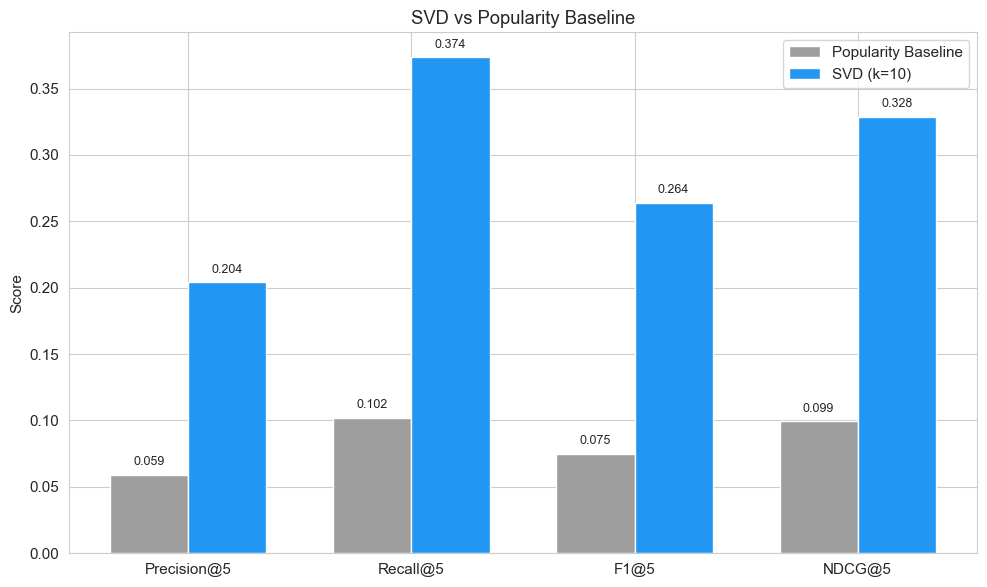

In [14]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics_labels = ['Precision@5', 'Recall@5', 'F1@5', 'NDCG@5']
pop_vals = [popularity_metrics[m] for m in metrics_names]
svd_vals = [best_svd_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_labels))
width = 0.35

bars1 = ax.bar(x - width/2, pop_vals, width, label='Popularity Baseline', color='#9E9E9E', edgecolor='white')
bars2 = ax.bar(x + width/2, svd_vals, width, label=f'SVD (k={best_k})', color='#2196F3', edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('SVD vs Popularity Baseline')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Final SVD Model — Build with Best k

In [15]:
# Rebuild final SVD with best k on the full training data
U, sigma, Vt = svds(train_sparse, k=best_k)
sigma_diag = np.diag(sigma)
predicted_ratings = np.dot(np.dot(U, sigma_diag), Vt) + user_means

# Store as DataFrame for easy lookup
pred_df = pd.DataFrame(predicted_ratings, index=user_ids, columns=item_names)

print(f'Final SVD model built with k={best_k}')
print(f'Predicted ratings matrix shape: {pred_df.shape}')
print(f'Score range: [{predicted_ratings.min():.3f}, {predicted_ratings.max():.3f}]')

Final SVD model built with k=10
Predicted ratings matrix shape: (9991, 122)
Score range: [-3.819, 31.381]


---
## 11. Latent Feature Analysis

The latent factors SVD extracts are abstract — they don't come with labels. But by looking at which items load highest on each factor, we can try to interpret what each factor captures.

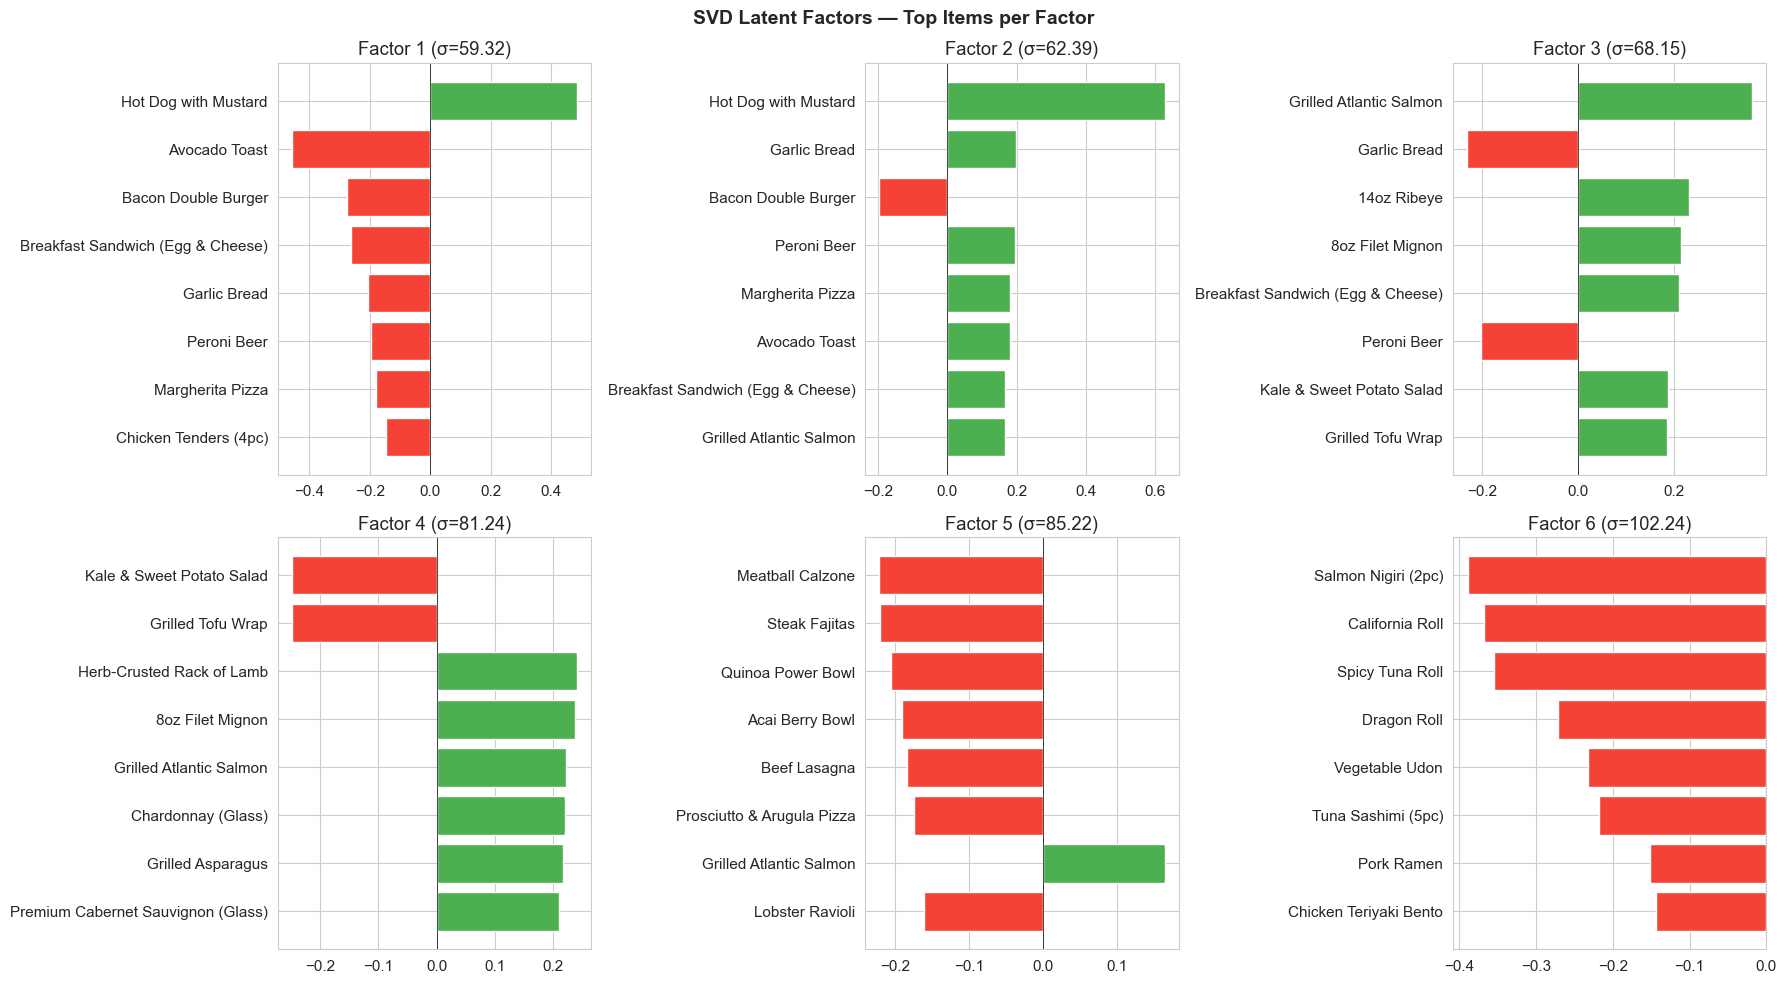


Interpretation: items with the same sign on a factor are "similar" in that latent dimension.
Positive vs negative loadings represent opposing tastes (e.g., coffee drinkers vs juice drinkers).


In [16]:
n_factors_to_show = min(best_k, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for factor_idx in range(n_factors_to_show):
    factor_loadings = Vt[factor_idx]
    top_indices = np.argsort(np.abs(factor_loadings))[-8:]  # Top 8 by absolute loading

    top_item_names = [item_names[i] for i in top_indices]
    top_loadings = [factor_loadings[i] for i in top_indices]

    colors = ['#4CAF50' if v > 0 else '#F44336' for v in top_loadings]
    axes[factor_idx].barh(top_item_names, top_loadings, color=colors, edgecolor='white')
    axes[factor_idx].set_title(f'Factor {factor_idx + 1} (σ={sigma[factor_idx]:.2f})')
    axes[factor_idx].axvline(0, color='black', linewidth=0.5)

# Hide unused subplots
for i in range(n_factors_to_show, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('SVD Latent Factors — Top Items per Factor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation: items with the same sign on a factor are "similar" in that latent dimension.')
print('Positive vs negative loadings represent opposing tastes (e.g., coffee drinkers vs juice drinkers).')

---
## 12. Item-Item Similarity from SVD Latent Space

Bonus: the SVD item embeddings (Vᵀ) give us a natural item-item similarity matrix. This serves as a **content-based fallback** for cold-start users (no purchase history).

In [17]:
# Items in latent space = Vt.T (each row is an item's k-dimensional vector)
item_latent = Vt.T  # shape: (n_items, k)
item_similarity = cosine_similarity(item_latent)
item_sim_df = pd.DataFrame(item_similarity, index=item_names, columns=item_names)

# Show similar items for examples
example_items = ['Espresso', 'Classic Cheeseburger', 'Spaghetti Carbonara', 'Steak Fajitas', 'Pork Ramen']

for item in example_items:
    if item in item_sim_df.columns:
        similar = item_sim_df[item].drop(item).nlargest(5)
        print(f'\nItems similar to "{item}":')
        for sim_item, score in similar.items():
            print(f'  {score:.3f}  {sim_item}')


Items similar to "Espresso":
  0.977  Everything Bagel with Cream Cheese
  0.970  Blueberry Muffin
  0.922  Chocolate Chip Cookie
  0.728  Black Tea
  0.639  Cold Brew Coffee

Items similar to "Classic Cheeseburger":
  0.934  Spicy BBQ Bacon Burger
  0.899  Crispy Chicken Sandwich
  0.867  Chicken Tenders (4pc)
  0.821  Coca-Cola
  0.817  Philly Cheesesteak

Items similar to "Spaghetti Carbonara":
  0.971  Pepperoni Pizza
  0.970  Beef Lasagna
  0.965  Meatball Calzone
  0.964  Prosciutto & Arugula Pizza
  0.964  Lobster Ravioli

Items similar to "Steak Fajitas":
  0.886  Pork Carnitas Bowl
  0.882  Cheese Quesadilla
  0.872  Chicken Enchiladas
  0.827  Beef Tacos (3pc)
  0.815  Chicken Burrito

Items similar to "Pork Ramen":
  0.941  Chicken Teriyaki Bento
  0.897  Vegetable Udon
  0.888  Miso Soup
  0.729  California Roll
  0.720  Hot Sake (Small)


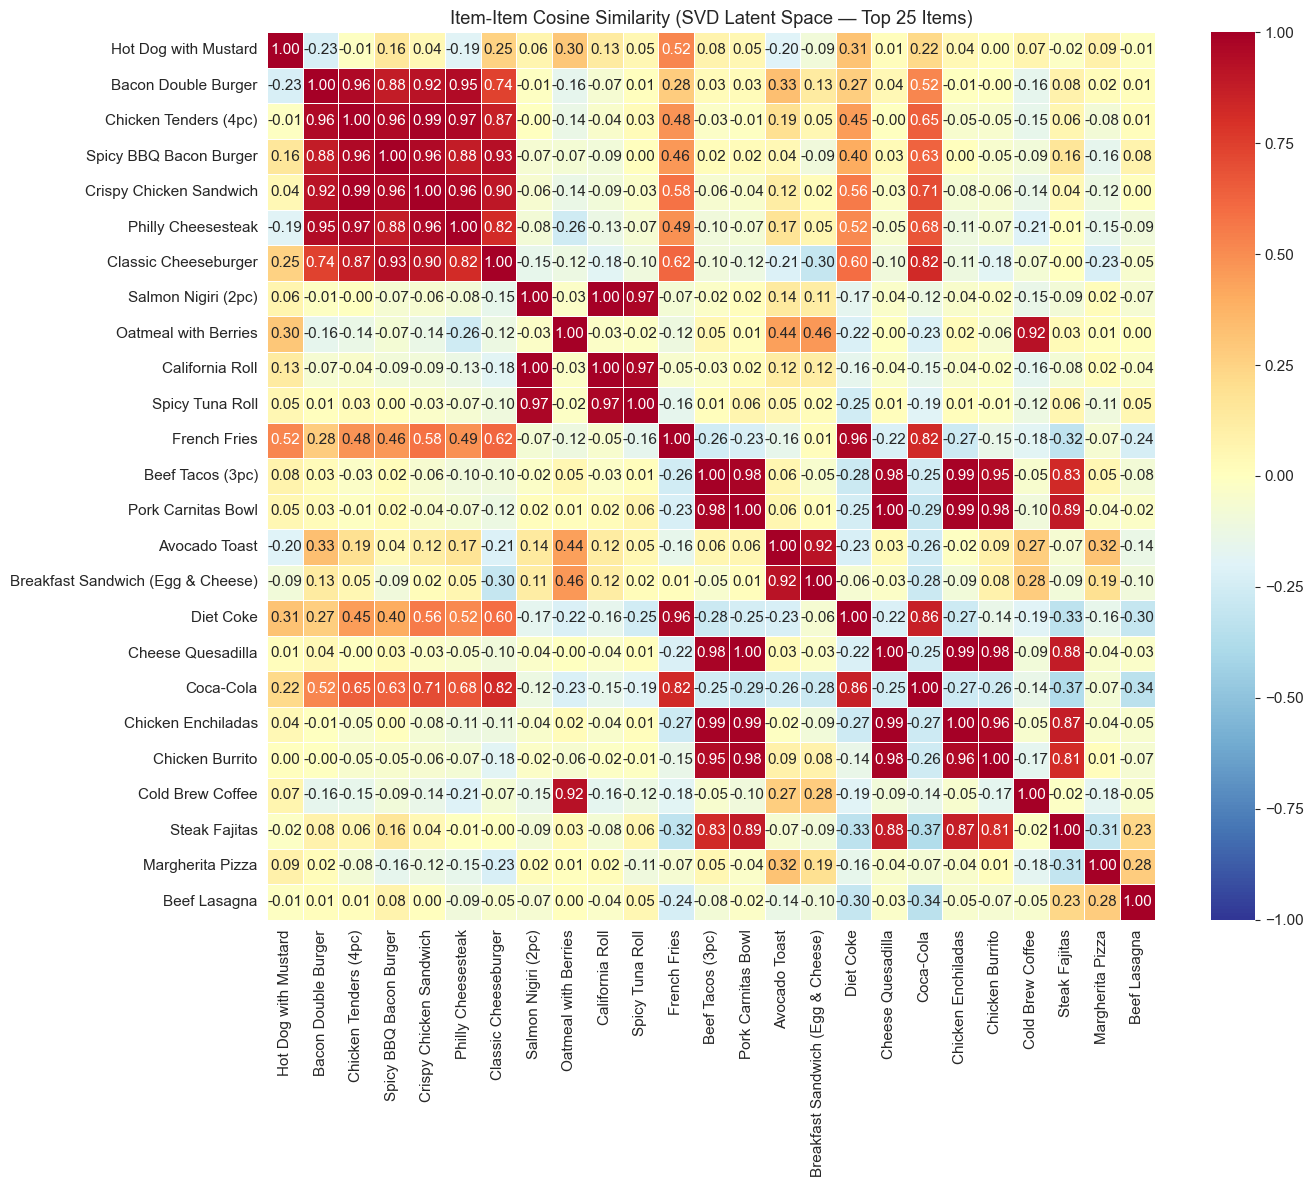

In [18]:
# Heatmap of item similarity for a subset
# Pick top 25 most popular items for readability
top_25_items = purchases_per_item.nlargest(25, 'unique_buyers')['item_name'].tolist()
sim_subset = item_sim_df.loc[top_25_items, top_25_items]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    sim_subset,
    annot=True, fmt='.2f', cmap='RdYlBu_r',
    linewidths=0.5, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Item-Item Cosine Similarity (SVD Latent Space — Top 25 Items)')
plt.tight_layout()
plt.show()

---
## 13. Demo — Generate Recommendations for Sample Customers

In [19]:
def get_svd_recommendations(customer_id, n=5):
    """Get top-N personalized SVD recommendations for a customer."""
    if customer_id not in user_id_to_idx:
        return None

    uid_idx = user_id_to_idx[customer_id]
    user_preds = predicted_ratings[uid_idx]

    # Exclude already purchased items
    already_purchased = set(user_item_matrix.columns[user_item_matrix.loc[customer_id] > 0])

    # Score unpurchased items
    item_scores = [(item, user_preds[i]) for i, item in enumerate(item_names) if item not in already_purchased]
    item_scores.sort(key=lambda x: x[1], reverse=True)
    return item_scores[:n]


# Pick demo customers from different archetypes
demo_customers = []
for archetype in ['regular', 'occasional', 'infrequent']:
    arch_customers = customers_df[customers_df['archetype'] == archetype]
    for _, c in arch_customers.iterrows():
        cid = c['customer_id']
        if cid in user_id_to_idx:
            n_purchased = (user_item_matrix.loc[cid] > 0).sum()
            if n_purchased >= 5:
                demo_customers.append(cid)
                break

print('=' * 70)
print('SVD RECOMMENDATION DEMOS')
print('=' * 70)

for cid in demo_customers:
    cust_info = customers_df[customers_df['customer_id'] == cid].iloc[0]
    purchased = user_item_matrix.loc[cid]
    purchased_items = purchased[purchased > 0].sort_values(ascending=False)

    print(f'  Customer {cid} ({cust_info["archetype"]}) | Sections: {cust_info["preferred_sections"]}')
    print(f'  Purchase history ({len(purchased_items)} unique items):')
    for item, count in purchased_items.head(8).items():
        print(f'    {item}: {int(count)}x')

    recs = get_svd_recommendations(cid, n=5)
    print(f'  → SVD Recommendations:')
    for item, score in recs:
        print(f'    {item} (score: {score:.3f})')
    print()

SVD RECOMMENDATION DEMOS
  Customer 447 (regular) | Sections: Cafe
  Purchase history (26 unique items):
    Oatmeal with Berries: 6x
    Avocado Toast: 5x
    Breakfast Sandwich (Egg & Cheese): 3x
    Chocolate Chip Cookie: 3x
    Almond Croissant: 3x
    Caramel Macchiato: 2x
    Blueberry Muffin: 2x
    Orange Juice: 2x
  → SVD Recommendations:
    Cold Brew Coffee (score: 1.350)
    Cappuccino (score: 0.693)
    Bacon Double Burger (score: 0.677)
    Chicken Tenders (4pc) (score: 0.524)
    Pork Ramen (score: 0.438)

  Customer 1774 (occasional) | Sections: Healthy_Vegan,American
  Purchase history (12 unique items):
    Coca-Cola: 4x
    Bacon Double Burger: 3x
    Chicken Tenders (4pc): 3x
    Classic Cheeseburger: 2x
    Crispy Chicken Sandwich: 1x
    Dr Pepper: 1x
    French Fries: 1x
    Hot Dog with Mustard: 1x
  → SVD Recommendations:
    Spicy BBQ Bacon Burger (score: 1.131)
    Philly Cheesesteak (score: 0.966)
    Diet Coke (score: 0.765)
    Buffalo Wings (10pc) (score:

---
## 14. Save Outputs

In [20]:
# Save predicted ratings matrix
pred_df.to_csv(os.path.join(SVD_DIR, 'svd_predicted_ratings.csv'))
print(f'Saved: svd_predicted_ratings.csv ({pred_df.shape})')

# Save item similarity matrix
item_sim_df.to_csv(os.path.join(SVD_DIR, 'svd_item_similarity_matrix.csv'))
print(f'Saved: svd_item_similarity_matrix.csv ({item_sim_df.shape})')

# Save evaluation results
eval_rows = [{'model': 'Popularity Baseline', **popularity_metrics}]
for k, metrics in sorted(svd_results.items()):
    eval_rows.append({'model': f'SVD (k={k})', **metrics})

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(os.path.join(SVD_DIR, 'svd_evaluation_results.csv'), index=False)
print(f'Saved: svd_evaluation_results.csv')

# Save latent factors for potential reuse
np.savez(
    os.path.join(SVD_DIR, 'svd_model_factors.npz'),
    U=U, sigma=sigma, Vt=Vt, user_means=user_means
)
print(f'Saved: svd_model_factors.npz (U, sigma, Vt, user_means)')

Saved: svd_predicted_ratings.csv ((9991, 122))
Saved: svd_item_similarity_matrix.csv ((122, 122))
Saved: svd_evaluation_results.csv
Saved: svd_model_factors.npz (U, sigma, Vt, user_means)


---
## 15. Summary & Conclusions

In [21]:
print('=' * 70)
print('SVD COLLABORATIVE FILTERING — SUMMARY')
print('=' * 70)
print(f'\nDataset: {n_users} users × {n_items} items | Sparsity: {sparsity:.1%}')
print(f'Best SVD config: k={best_k} latent factors')
print(f'\nFinal metrics comparison:')
print('-' * 70)
print_metrics('Popularity Baseline', popularity_metrics)
print_metrics(f'SVD (k={best_k})', best_svd_metrics)
print('-' * 70)

f1_improvement = (best_svd_metrics['f1@k'] - popularity_metrics['f1@k'])
if f1_improvement > 0:
    print(f'\n✅ SVD beats the popularity baseline by +{f1_improvement:.4f} F1@5.')
    print('   The model captures personalized patterns beyond raw popularity.')
else:
    print(f'\n⚠️  SVD does NOT beat the popularity baseline (delta: {f1_improvement:.4f} F1@5).')
    print('   Possible reasons: dataset too small, not enough interaction diversity, or high sparsity.')

print(f'\nKey characteristics of SVD:')
print(f'  - Direct decomposition (no iterative training, no loss function)')
print(f'  - Fast to compute, deterministic given the same input')
print(f'  - Requires mean-centering for best results')
print(f'  - Cannot handle new users/items without re-decomposition')
print(f'\n→ Next: Compare with ALS (which IS iterative training) in notebook 02b.')

SVD COLLABORATIVE FILTERING — SUMMARY

Dataset: 9991 users × 122 items | Sparsity: 89.5%
Best SVD config: k=10 latent factors

Final metrics comparison:
----------------------------------------------------------------------
  Popularity Baseline       | Precision@5: 0.0590 | Recall@5: 0.1018 | F1@5: 0.0747 | NDCG@5: 0.0994
  SVD (k=10)                | Precision@5: 0.2040 | Recall@5: 0.3736 | F1@5: 0.2639 | NDCG@5: 0.3285
----------------------------------------------------------------------

✅ SVD beats the popularity baseline by +0.1892 F1@5.
   The model captures personalized patterns beyond raw popularity.

Key characteristics of SVD:
  - Direct decomposition (no iterative training, no loss function)
  - Fast to compute, deterministic given the same input
  - Requires mean-centering for best results
  - Cannot handle new users/items without re-decomposition

→ Next: Compare with ALS (which IS iterative training) in notebook 02b.
